### Mission 3 — Modélisation et comparaison rigoureuse
Objectifs : battre significativement la baseline naïve, comparer 3 familles
de modèles avec les mêmes plis de validation croisée, tester si l'écart
entre les 2 meilleurs est statistiquement significatif, analyser les erreurs.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier

from src.preprocessing import build_pipeline, load_data

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

naive_pipeline = build_pipeline(DummyClassifier(strategy="most_frequent"))
naive_scores = cross_validate(naive_pipeline, X_train, y_train, cv=cv,
                               scoring=["recall", "f1", "accuracy"])

print("=== Baseline naïve (toujours 'pas de churn') ===")
print(f"Rappel  : {naive_scores['test_recall'].mean():.3f}")
print(f"F1      : {naive_scores['test_f1'].mean():.3f}")
print(f"Accuracy: {naive_scores['test_accuracy'].mean():.3f}")

=== Baseline naïve (toujours 'pas de churn') ===
Rappel  : 0.000
F1      : 0.000
Accuracy: 0.735


### 1. Comparaison de 3 familles de modèles

Régression logistique (linéaire), forêt aléatoire (arbres), SVM (noyaux) —
évalués sur exactement les mêmes plis de validation croisée (StratifiedKFold, 5 plis).

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Régression logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Forêt aléatoire": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    pipe = build_pipeline(model)
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                             scoring=["recall", "f1", "accuracy"])
    results[name] = scores
    print(f"{name:25s} rappel = {scores['test_recall'].mean():.3f} ± {scores['test_recall'].std():.3f}")

print()
for name, scores in results.items():
    print(f"{name:25s} F1 = {scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}"
          f"   Accuracy = {scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}")

Régression logistique     rappel = 0.544 ± 0.041
Forêt aléatoire           rappel = 0.476 ± 0.028
SVM (RBF)                 rappel = 0.498 ± 0.015

Régression logistique     F1 = 0.592 ± 0.030   Accuracy = 0.802 ± 0.012
Forêt aléatoire           F1 = 0.540 ± 0.025   Accuracy = 0.785 ± 0.012
SVM (RBF)                 F1 = 0.575 ± 0.014   Accuracy = 0.805 ± 0.007


### Stabilité des modèles (boxplot par pli)

Visualisation de la distribution du rappel sur les 5 plis pour chaque modèle.

C:\Users\DELL 5430\AppData\Local\Temp\ipykernel_28296\1123261431.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=list(models.keys()))


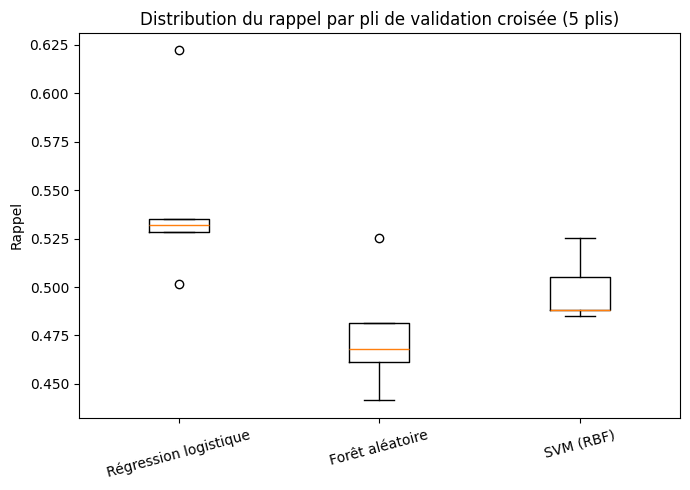

Régression logistique     plis individuels : [0.535 0.502 0.532 0.622 0.528]
Forêt aléatoire           plis individuels : [0.482 0.441 0.525 0.462 0.468]
SVM (RBF)                 plis individuels : [0.488 0.485 0.505 0.525 0.488]


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
data_to_plot = [results[name]["test_recall"] for name in models.keys()]
ax.boxplot(data_to_plot, labels=list(models.keys()))
ax.set_ylabel("Rappel")
ax.set_title("Distribution du rappel par pli de validation croisée (5 plis)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for name in models.keys():
    print(f"{name:25s} plis individuels : {results[name]['test_recall'].round(3)}")

### 2. Test statistique entre les 2 meilleurs modèles

Test de Wilcoxon (données appariées, mêmes plis) entre la régression
logistique et le SVM, les deux meilleurs modèles sur le rappel.

In [4]:
from scipy.stats import wilcoxon

lr_scores = results["Régression logistique"]["test_recall"]
svm_scores = results["SVM (RBF)"]["test_recall"]

stat, p_value = wilcoxon(lr_scores, svm_scores)
print(f"Statistique de Wilcoxon : {stat:.3f}")
print(f"p-valeur : {p_value:.4f}")
print(f"Différence par pli (LR - SVM) : {(lr_scores - svm_scores).round(3)}")

if p_value < 0.05:
    print("\n-> Différence statistiquement significative (p < 0.05).")
else:
    print("\n-> Différence NON statistiquement significative (p >= 0.05).")

Statistique de Wilcoxon : 0.000
p-valeur : 0.0625
Différence par pli (LR - SVM) : [0.047 0.017 0.027 0.097 0.04 ]

-> Différence NON statistiquement significative (p >= 0.05).


### 3. Analyse d'erreurs

Profil des faux négatifs (churners ratés par le meilleur modèle) comparé
aux vrais positifs (churners bien détectés), pour identifier un pattern
exploitable en feature engineering.

In [5]:
from sklearn.model_selection import cross_val_predict

best_pipeline = build_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
y_pred = cross_val_predict(best_pipeline, X_train, y_train, cv=cv)

X_analysis = X_train.copy()
X_analysis["y_true"] = y_train.values
X_analysis["y_pred"] = y_pred

false_negatives = X_analysis[(X_analysis["y_true"] == 1) & (X_analysis["y_pred"] == 0)]
true_positives = X_analysis[(X_analysis["y_true"] == 1) & (X_analysis["y_pred"] == 1)]

print(f"Faux négatifs (churners ratés) : {len(false_negatives)}")
print(f"Vrais positifs (churners détectés) : {len(true_positives)}")

print("\n--- Profil des FAUX NÉGATIFS (churners ratés) ---")
print("Contract :\n", false_negatives["Contract"].value_counts(normalize=True).round(2))
print("\ntenure médiane :", false_negatives["tenure"].median())
print("MonthlyCharges médian :", false_negatives["MonthlyCharges"].median())

print("\n--- Profil des VRAIS POSITIFS (churners détectés, pour comparaison) ---")
print("Contract :\n", true_positives["Contract"].value_counts(normalize=True).round(2))
print("\ntenure médiane :", true_positives["tenure"].median())
print("MonthlyCharges médian :", true_positives["MonthlyCharges"].median())

Faux négatifs (churners ratés) : 682
Vrais positifs (churners détectés) : 813

--- Profil des FAUX NÉGATIFS (churners ratés) ---
Contract :
 Contract
Month-to-month    0.75
One year          0.19
Two year          0.06
Name: proportion, dtype: float64

tenure médiane : 25.0
MonthlyCharges médian : 69.05

--- Profil des VRAIS POSITIFS (churners détectés, pour comparaison) ---
Contract :
 Contract
Month-to-month    1.0
Name: proportion, dtype: float64

tenure médiane : 6.0
MonthlyCharges médian : 84.45


## 4. Conclusion — Mission 3

| | Rappel (CV) | Stabilité (écart-type) |
|---|---|---|
| Baseline naïve | 0,000 | — |
| **Régression logistique (retenue)** | **0,544 ± 0,041** | Moyenne |
| Forêt aléatoire | 0,476 ± 0,028 | Moyenne |
| SVM (RBF) | 0,498 ± 0,015 | **La plus stable** |

Les 3 modèles battent largement la baseline naïve (rappel 0). La régression
logistique obtient le meilleur rappel, mais l'écart avec le SVM n'est
**pas statistiquement significatif** (Wilcoxon, p=0,0625) — limite due au
faible nombre de plis (5), qui plafonne mécaniquement la puissance du test.
Le SVM est le modèle le plus stable d'un pli à l'autre.

**Analyse d'erreurs :** le meilleur modèle détecte bien le churn chez les
clients récents en contrat mensuel (100% des vrais positifs), mais rate
25% des churners en contrat plus long (ancienneté médiane 25 mois) — un
churn "inattendu" chez des clients apparemment fidèles, non capturé par
les features disponibles. Limite documentée, aucune feature du dataset ne
permet actuellement de corriger ce point.

**Modèle retenu pour la Mission 4 (tuning) : régression logistique.**